# Clean Data Plots and Fits

This notebook explains and plots the two exported files:

- `clean_data.csv`: normal mapped packets. Each row is one accepted 34-byte uplink packet reliably assigned to one normal manual/JSON position window.
- `longer_sampling_per_position.csv`: longer-sampling packets. It contains tail samples plus the requested group 7 rows for `R1352`, `R1189`, and `R1187`.

The main measured columns are `rssi` for signal strength and `snr` for signal-to-noise ratio. The main mapping columns are `structure_id`, `manual_group`, `x_m`, and the interval timestamps used to assign a packet to a position.

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("outputs/tests_gh_25_06")
clean_data = pd.read_csv(DATA_DIR / "clean_data.csv")
longer_sampling = pd.read_csv(DATA_DIR / "longer_sampling_per_position.csv")

def group_to_x_m(group, structure_id=None):
    """Convert a mapped group number to its physical x position in meters."""
    if pd.isna(group):
        return np.nan
    group = int(group)

    structure_num = None
    if structure_id is not None and pd.notna(structure_id):
        structure_num = int(str(structure_id).lstrip("R"))

    if structure_num is not None and structure_num < 1300:
        x_m = -(group - 1) * 15 + 4
        if group == 12:
            x_m -= 8.5
        return x_m

    x_m = (group - 1) * 15 - 2
    if group == 12:
        x_m += 8.5
    return x_m


def structure_to_y_m(structure_id):
    """Convert structure/row id to physical y position in meters."""
    if pd.isna(structure_id):
        return np.nan
    structure_num = int(str(structure_id).lstrip("R"))
    if structure_num >= 1300:
        return (structure_num - 1355) * 1.6
    return (1186 - structure_num) * 1.6



for frame in (clean_data, longer_sampling):
    if "manual_group" in frame.columns:
        frame["x_m"] = frame.apply(lambda row: group_to_x_m(row["manual_group"], row.get("structure_id")), axis=1)
        frame["y_m"] = frame["structure_id"].apply(structure_to_y_m)
        if "longer_sampling_source" in frame.columns:
            tail_mask = frame["longer_sampling_source"].eq("tail")
            frame.loc[tail_mask, "x_m"] = frame.loc[tail_mask, "structure_id"].apply(lambda structure_id: group_to_x_m(7, structure_id))

time_cols = ["time_local", "registered_start_time", "interval_start_time", "interval_end_time"]
for frame in (clean_data, longer_sampling):
    for col in time_cols:
        if col in frame.columns:
            frame[col] = pd.to_datetime(frame[col], errors="coerce")

clean_data["mapped_row_id"] = np.arange(len(clean_data))
longer_sampling["mapped_row_id"] = np.arange(len(longer_sampling))

print(f"clean_data: {clean_data.shape[0]} rows, {clean_data.shape[1]} columns")
print(f"longer_sampling_per_position: {longer_sampling.shape[0]} rows, {longer_sampling.shape[1]} columns")


clean_data: 540 rows, 61 columns
longer_sampling_per_position: 202 rows, 62 columns


## Structure of the Files

Each row is one measured packet. The important column groups are:

- Actual mapped row: `mapped_row_id`, `source_file`, `time_local`, `fcnt`, `type`, `size`, `structure_id`, `manual_group`, `manual_group_status`, `manual_group_reliable`.
- Position: `x_m` is the physical position along the row and `y_m` is the physical row offset. For `R13xx`, `x_m = (manual_group - 1) * 15 - 2`, with group 12 shifted by `+8.5 m`. For `R11xx`, `x_m = -(manual_group - 1) * 15 + 4`, with group 12 shifted by `-8.5 m`. For row spacing, `R1355` and `R1186` are at `y_m = 0`, and each row number step is `1.6 m`.
- Mapping interval: `registered_start_time`, `interval_start_time`, `interval_end_time`, `is_final_group`, `is_extra_tail_group` describe the time window that accepted the packet.
- Signal measurements: `rssi` is received signal strength in dBm. `snr` is signal-to-noise ratio in dB.

`longer_sampling_per_position.csv` also has `longer_sampling_source`, with `tail` for tail samples and `group_7` for the added group 7 samples.


In [22]:
key_cols = [
    "mapped_row_id", "source_file", "time_local", "fcnt", "type", "size",
    "structure_id", "manual_group", "manual_group_status", "manual_group_reliable",
    "x_m", "registered_start_time", "interval_start_time", "interval_end_time",
    "is_final_group", "is_extra_tail_group", "rssi", "snr", "longer_sampling_source",
]

display(clean_data[[c for c in key_cols if c in clean_data.columns]].head(12))

clean_position_summary = (
    clean_data.groupby(["structure_id", "manual_group", "x_m"], dropna=False)
    .agg(rows=("mapped_row_id", "count"), mean_rssi=("rssi", "mean"), std_rssi=("rssi", "std"), mean_snr=("snr", "mean"), std_snr=("snr", "std"))
    .reset_index()
    .sort_values(["structure_id", "manual_group"])
)
display(clean_position_summary.head(20))

display(longer_sampling["longer_sampling_source"].value_counts().rename_axis("source").to_frame("rows"))
display(longer_sampling[[c for c in key_cols if c in longer_sampling.columns]].head(12))

,mapped_row_id,source_file,time_local,fcnt,type,size,structure_id,manual_group,manual_group_status,manual_group_reliable,x_m,registered_start_time,interval_start_time,interval_end_time,is_final_group,is_extra_tail_group,rssi,snr
0,0,25-6_r1354.csv,2026-06-25 10:33:58+02:00,58,UpUnc,34,R1354,1,assigned_manual_window,True,-60.0,2026-06-25 10:33:58+02:00,2026-06-25 10:33:55+02:00,2026-06-25 10:38:27+02:00,False,False,-41.0,13.2
1,1,25-6_r1354.csv,2026-06-25 10:34:01+02:00,59,UpUnc,34,R1354,1,assigned_manual_window,True,-60.0,2026-06-25 10:33:58+02:00,2026-06-25 10:33:55+02:00,2026-06-25 10:38:27+02:00,False,False,-40.0,11.2
2,2,25-6_r1354.csv,2026-06-25 10:36:52+02:00,62,UpUnc,34,R1354,1,assigned_manual_window,True,-60.0,2026-06-25 10:33:58+02:00,2026-06-25 10:33:55+02:00,2026-06-25 10:38:27+02:00,False,False,-40.0,11.0
3,3,25-6_r1354.csv,2026-06-25 10:36:57+02:00,63,UpUnc,34,R1354,1,assigned_manual_window,True,-60.0,2026-06-25 10:33:58+02:00,2026-06-25 10:33:55+02:00,2026-06-25 10:38:27+02:00,False,False,-41.0,12.8
4,4,25-6_r1354.csv,2026-06-25 10:38:27+02:00,66,UpUnc,34,R1354,2,assigned_manual_window,True,-45.0,2026-06-25 10:38:30+02:00,2026-06-25 10:38:27+02:00,2026-06-25 10:39:47+02:00,False,False,-52.0,10.2
5,5,25-6_r1354.csv,2026-06-25 10:38:31+02:00,67,UpUnc,34,R1354,2,assigned_manual_window,True,-45.0,2026-06-25 10:38:30+02:00,2026-06-25 10:38:27+02:00,2026-06-25 10:39:47+02:00,False,False,-51.0,14.2
6,6,25-6_r1354.csv,2026-06-25 10:38:43+02:00,70,UpUnc,34,R1354,2,assigned_manual_window,True,-45.0,2026-06-25 10:38:30+02:00,2026-06-25 10:38:27+02:00,2026-06-25 10:39:47+02:00,False,False,-52.0,14.2
7,7,25-6_r1354.csv,2026-06-25 10:38:49+02:00,71,UpUnc,34,R1354,2,assigned_manual_window,True,-45.0,2026-06-25 10:38:30+02:00,2026-06-25 10:38:27+02:00,2026-06-25 10:39:47+02:00,False,False,-52.0,14.2
8,8,25-6_r1354.csv,2026-06-25 10:38:59+02:00,73,UpUnc,34,R1354,2,assigned_manual_window,True,-45.0,2026-06-25 10:38:30+02:00,2026-06-25 10:38:27+02:00,2026-06-25 10:39:47+02:00,False,False,-55.0,14.2
9,9,25-6_r1354.csv,2026-06-25 10:39:04+02:00,74,UpUnc,34,R1354,2,assigned_manual_window,True,-45.0,2026-06-25 10:38:30+02:00,2026-06-25 10:38:27+02:00,2026-06-25 10:39:47+02:00,False,False,-58.0,13.8


,structure_id,manual_group,x_m,rows,mean_rssi,std_rssi,mean_snr,std_snr
0,R1183,1,-60.0,4,-48.250000,7.088723,13.675000,0.699405
1,R1183,2,-45.0,6,-62.333333,8.430105,12.383333,2.069219
2,R1183,3,-30.0,5,-74.400000,2.966479,13.300000,1.191638
3,R1183,4,-15.0,5,-92.600000,6.804410,8.000000,4.923413
4,R1183,5,0.0,7,-87.857143,6.094494,9.828571,2.994837
5,R1183,6,15.0,5,-98.400000,7.503333,3.600000,4.934065
6,R1183,7,30.0,7,-93.285714,1.380131,8.214286,3.022377
7,R1183,8,45.0,4,-95.000000,4.830459,6.850000,3.837968
8,R1183,9,60.0,3,-102.333333,2.081666,1.833333,2.218859
9,R1183,10,75.0,2,-104.000000,2.828427,-1.350000,4.454773


,rows
source,
tail,151
group_7,51


,mapped_row_id,source_file,time_local,fcnt,type,size,structure_id,manual_group,manual_group_status,manual_group_reliable,x_m,registered_start_time,interval_start_time,interval_end_time,is_final_group,is_extra_tail_group,rssi,snr,longer_sampling_source
0,0,25-6_r1356.csv,2026-06-25 11:24:09+02:00,292,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-84.0,13.8,tail
1,1,25-6_r1356.csv,2026-06-25 11:24:14+02:00,293,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-83.0,10.5,tail
2,2,25-6_r1356.csv,2026-06-25 11:24:23+02:00,295,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-83.0,10.0,tail
3,3,25-6_r1356.csv,2026-06-25 11:24:33+02:00,297,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-84.0,13.5,tail
4,4,25-6_r1356.csv,2026-06-25 11:24:37+02:00,298,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-84.0,12.8,tail
5,5,25-6_r1356.csv,2026-06-25 11:24:45+02:00,300,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-84.0,13.2,tail
6,6,25-6_r1356.csv,2026-06-25 11:24:50+02:00,301,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-84.0,13.0,tail
7,7,25-6_r1356.csv,2026-06-25 11:24:59+02:00,303,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-84.0,13.2,tail
8,8,25-6_r1356.csv,2026-06-25 11:25:03+02:00,304,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-90.0,9.8,tail
9,9,25-6_r1356.csv,2026-06-25 11:25:11+02:00,306,UpUnc,34,R1356,13,assigned_extra_tail,True,120.0,2026-06-25 11:24:09+02:00,2026-06-25 11:24:09+02:00,NaT,True,True,-89.0,6.5,tail


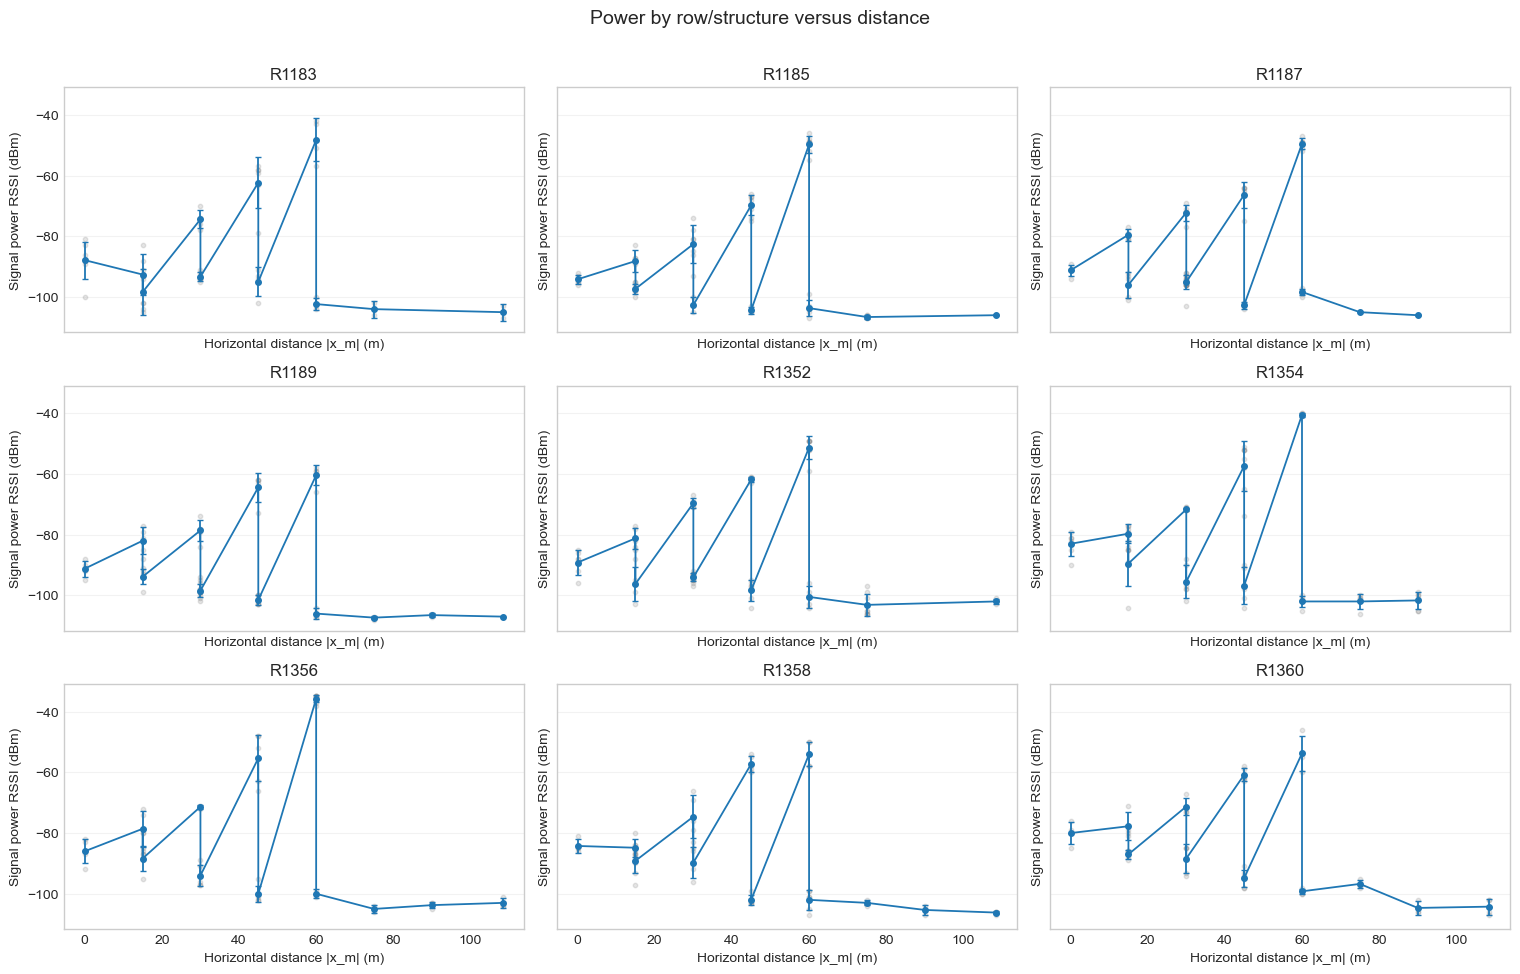

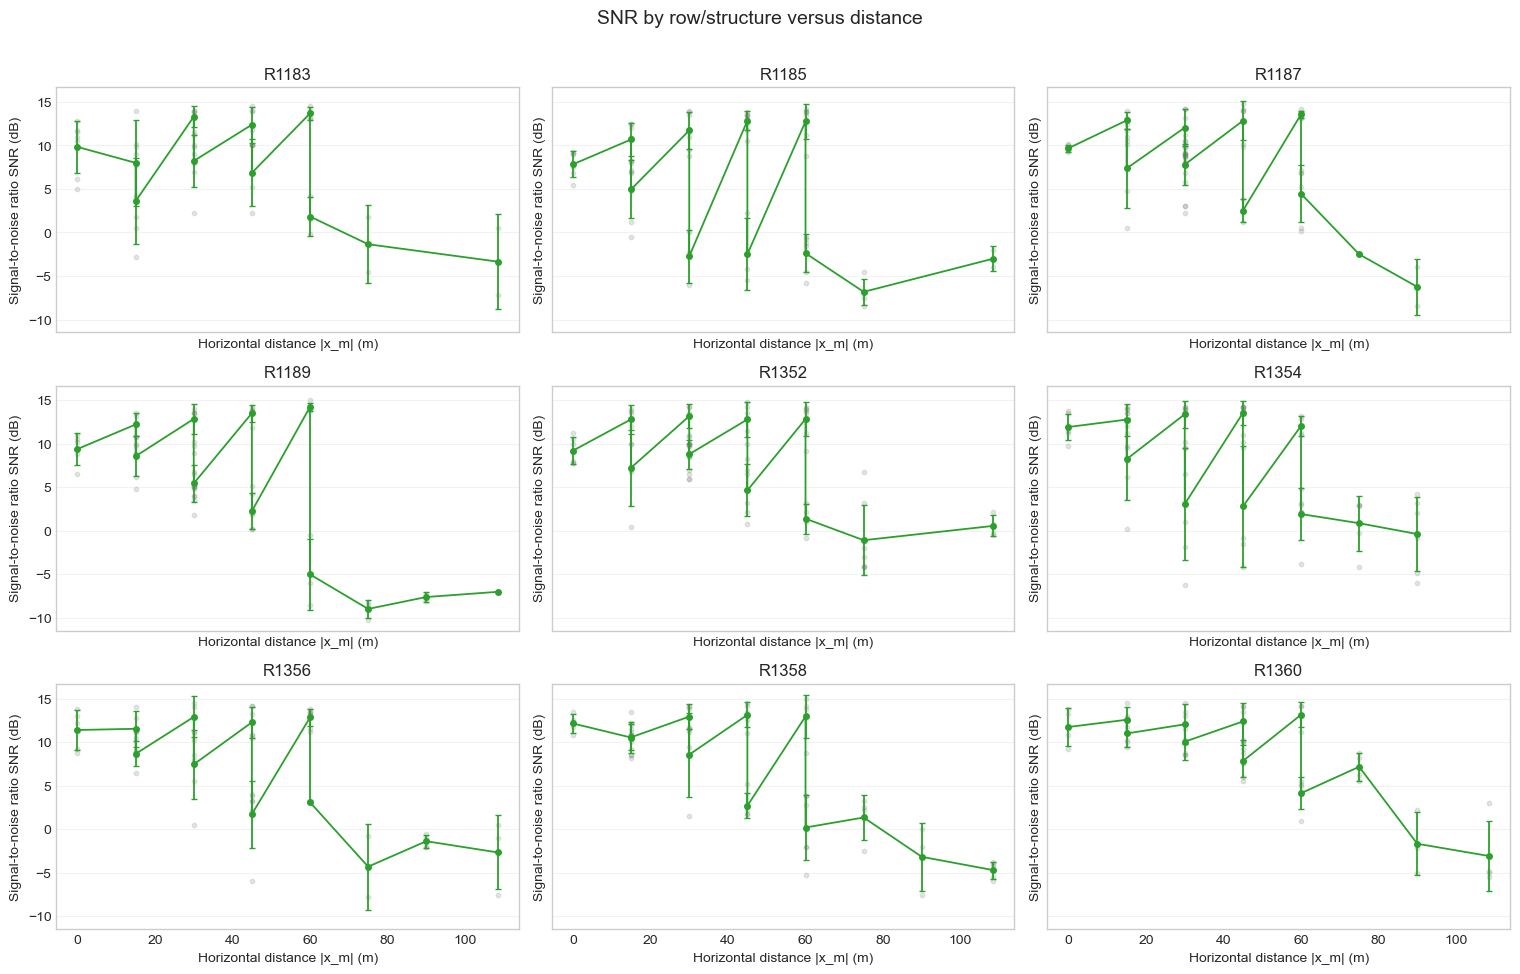

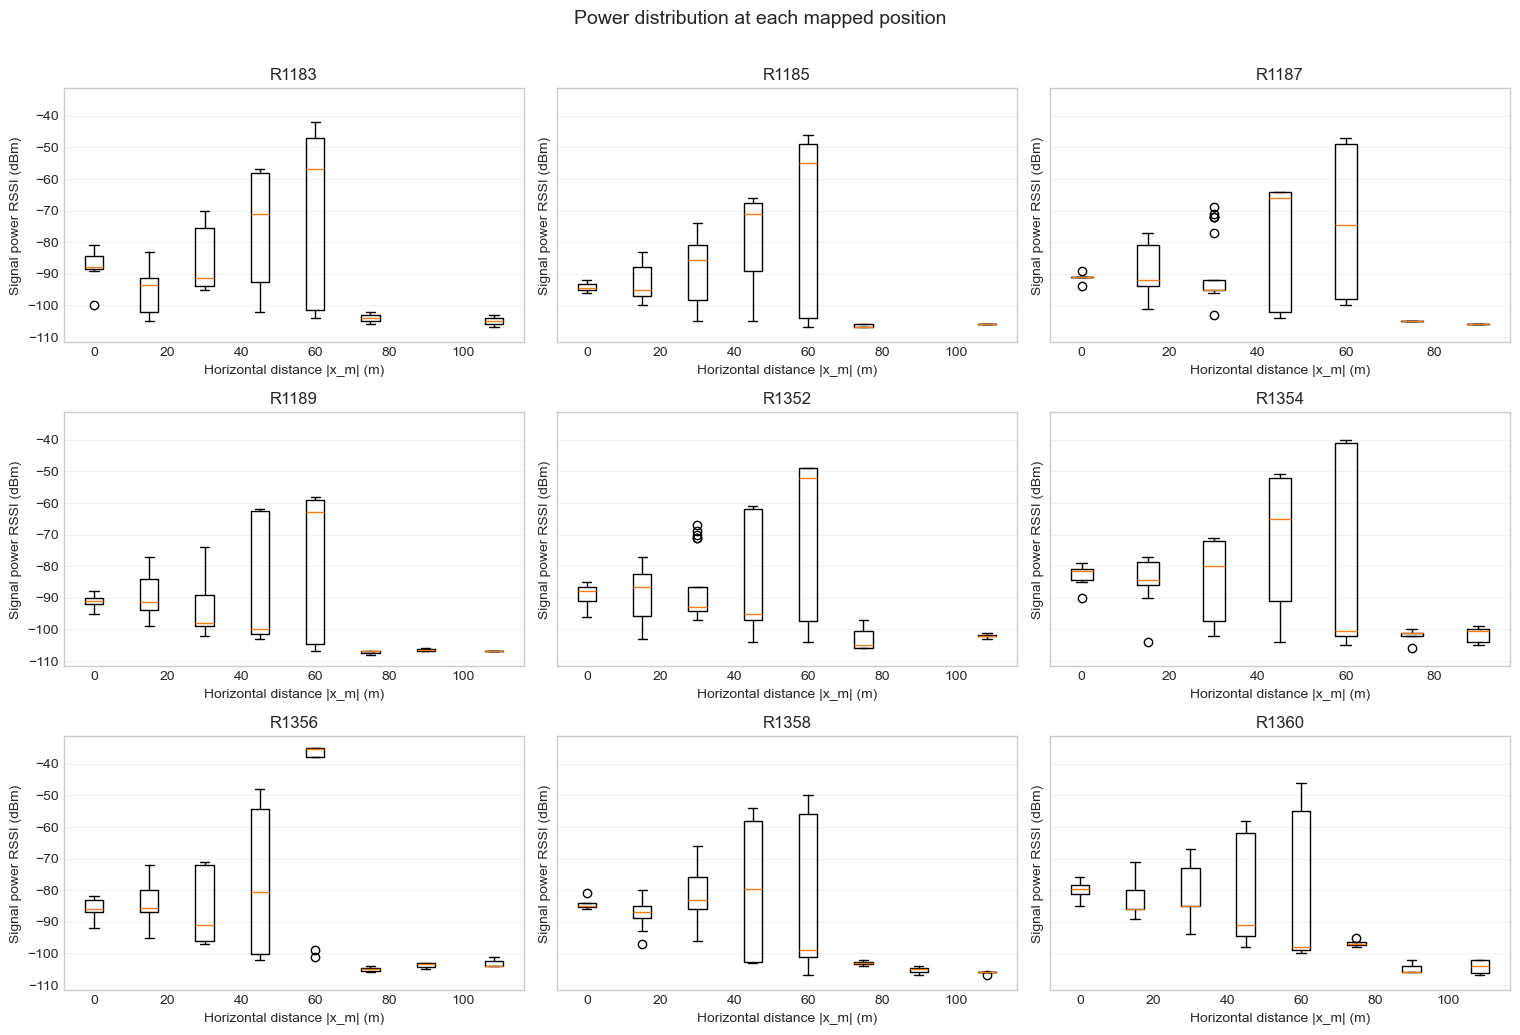

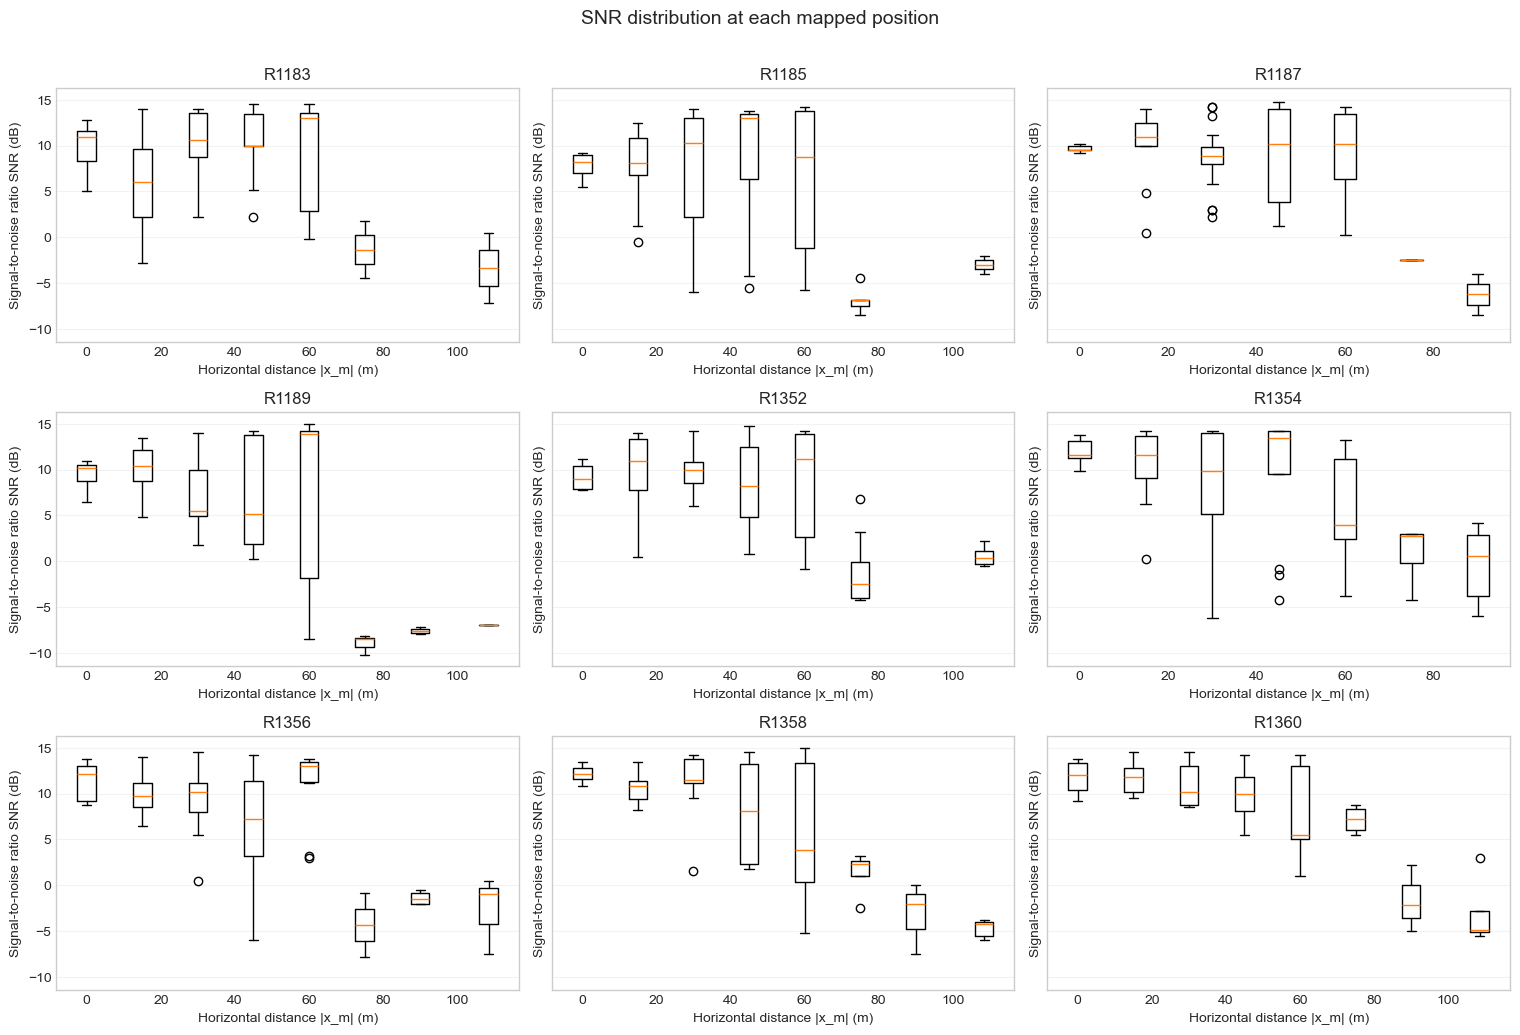

,structure_id,manual_group,x_m,horizontal_distance_m,packets,mean_power_dbm,std_power_db,mean_snr_db,std_snr_db
4,R1183,5,0.0,0.0,7,-87.857143,6.094494,9.828571,2.994837
3,R1183,4,-15.0,15.0,5,-92.600000,6.804410,8.000000,4.923413
5,R1183,6,15.0,15.0,5,-98.400000,7.503333,3.600000,4.934065
2,R1183,3,-30.0,30.0,5,-74.400000,2.966479,13.300000,1.191638
6,R1183,7,30.0,30.0,7,-93.285714,1.380131,8.214286,3.022377
1,R1183,2,-45.0,45.0,6,-62.333333,8.430105,12.383333,2.069219
7,R1183,8,45.0,45.0,4,-95.000000,4.830459,6.850000,3.837968
0,R1183,1,-60.0,60.0,4,-48.250000,7.088723,13.675000,0.699405
8,R1183,9,60.0,60.0,3,-102.333333,2.081666,1.833333,2.218859
9,R1183,10,75.0,75.0,2,-104.000000,2.828427,-1.350000,4.454773


In [ ]:
# Simple checking plots: one structure at a time.
# x_m follows group_to_x_m: R13xx moves right, R11xx moves left.
signal_data = clean_data[["structure_id", "manual_group", "x_m", "rssi", "snr"]].copy()
signal_data = signal_data.dropna(subset=["structure_id", "manual_group", "x_m"])
signal_data["position_m"] = signal_data["x_m"]

signal_summary = (
    signal_data.groupby(["structure_id", "manual_group", "position_m"], as_index=False)
    .agg(mean_rssi=("rssi", "mean"), mean_snr=("snr", "mean"), n=("rssi", "count"))
    .sort_values(["structure_id", "position_m", "manual_group"])
)

structures = sorted(signal_data["structure_id"].dropna().unique())

# 1) Mean signal per mapped physical position.
for metric, mean_col, ylabel in [("rssi", "mean_rssi", "Power / RSSI (dBm)"), ("snr", "mean_snr", "SNR (dB)")]:
    fig, axes = plt.subplots(len(structures), 1, figsize=(8, 2.2 * len(structures)), sharex=True)
    for ax, structure_id in zip(np.ravel(axes), structures):
        raw = signal_data[signal_data["structure_id"] == structure_id]
        avg = signal_summary[signal_summary["structure_id"] == structure_id]
        ax.scatter(raw["position_m"], raw[metric], s=10, alpha=0.25, color="0.55")
        ax.plot(avg["position_m"], avg[mean_col], "o-", color="tab:blue")
        ax.set_title(structure_id)
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.25)
    axes[-1].set_xlabel("Mapped physical position x_m (m)")
    fig.suptitle(f"{ylabel} by mapped physical position", y=1.0)
    plt.tight_layout()
    plt.show()

# 2) Box-and-whisker plots: packets at the same mapped position/group.
for metric, ylabel in [("rssi", "Power / RSSI (dBm)"), ("snr", "SNR (dB)")]:
    for structure_id in structures:
        row = signal_data[signal_data["structure_id"] == structure_id].dropna(subset=[metric])
        row = row.sort_values(["position_m", "manual_group"])
        positions = row[["manual_group", "position_m"]].drop_duplicates()
        values = [
            row.loc[(row["manual_group"] == g) & (row["position_m"] == x), metric].to_numpy()
            for g, x in positions[["manual_group", "position_m"]].itertuples(index=False)
        ]
        labels = [f"G{int(g)}\n{x:g}m" for g, x in positions[["manual_group", "position_m"]].itertuples(index=False)]
        plt.figure(figsize=(9, 3))
        plt.boxplot(values, labels=labels, showfliers=True)
        plt.title(f"{structure_id}: {ylabel} by mapped position")
        plt.xlabel("Manual group and x_m")
        plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

# Quick check: same signed position should not contain multiple groups unless that is expected.
position_group_check = (
    signal_data.groupby(["structure_id", "position_m"])["manual_group"]
    .nunique()
    .reset_index(name="groups_at_same_position")
)
display(position_group_check[position_group_check["groups_at_same_position"] > 1])
display(signal_summary.head(30))


## Physically Motivated Fit

Start with the simplest physical baseline: a single-medium log-distance path-loss model. After that baseline, compare it with a two-media model. The antenna is elevated on a pole, roughly in the 4-5 m range, while the tomato foliage is lower, roughly in the 3-4 m range. Close to the pole, part of the line of sight can travel above the crop. Farther into the row, the ray spends more of its path inside the foliage, so the two-media model adds attenuation from the foliage length.

The plots show signal strength/SNR against horizontal distance on a linear x-axis. The logarithm is used inside the fitted model, not as an axis scale.

Two models are compared. The single-medium model assumes one effective propagation medium:

`metric = A - alpha_log log10(d_3d / d0)`

The two-media model adds attenuation from the part of the path that crosses tomato foliage:

`metric = A - alpha_log log10(d_3d / d0) - alpha_foliage L_foliage`

`d_3d` is the slanted 3D path length from the antenna height to the receiver height. `L_foliage` is the approximate part of the horizontal path after the ray has entered the tomato canopy and after the crop begins along the row. For RSSI, `alpha_log` is related to the path-loss exponent, and `alpha_foliage` is an extra attenuation in dB per meter of foliage. For SNR, the same variables are used as an empirical trend because SNR also depends on noise and interference.

Yes: making the log transform first is the cleaner fit. Since RSSI is measured in dB, the usual multiplicative power-law path loss becomes linear in `log10(distance)`. Adding foliage length as another linear predictor keeps the minimization as a convex linear least-squares problem. The code uses bounded least squares so `alpha_log >= 0` and `alpha_foliage >= 0`; this avoids fits that improve numerically by making distance increase the signal, which would be physically backwards.

The height parameters are approximate. The effective crop-start distance is selected by a small grid search, and each candidate still uses the same bounded linear least-squares fit. If we measure the geometry more precisely, update the constants in the next cell. Fit quality is summarized by `R2`, adjusted `R2`, RMSE, and the fitted coefficients.

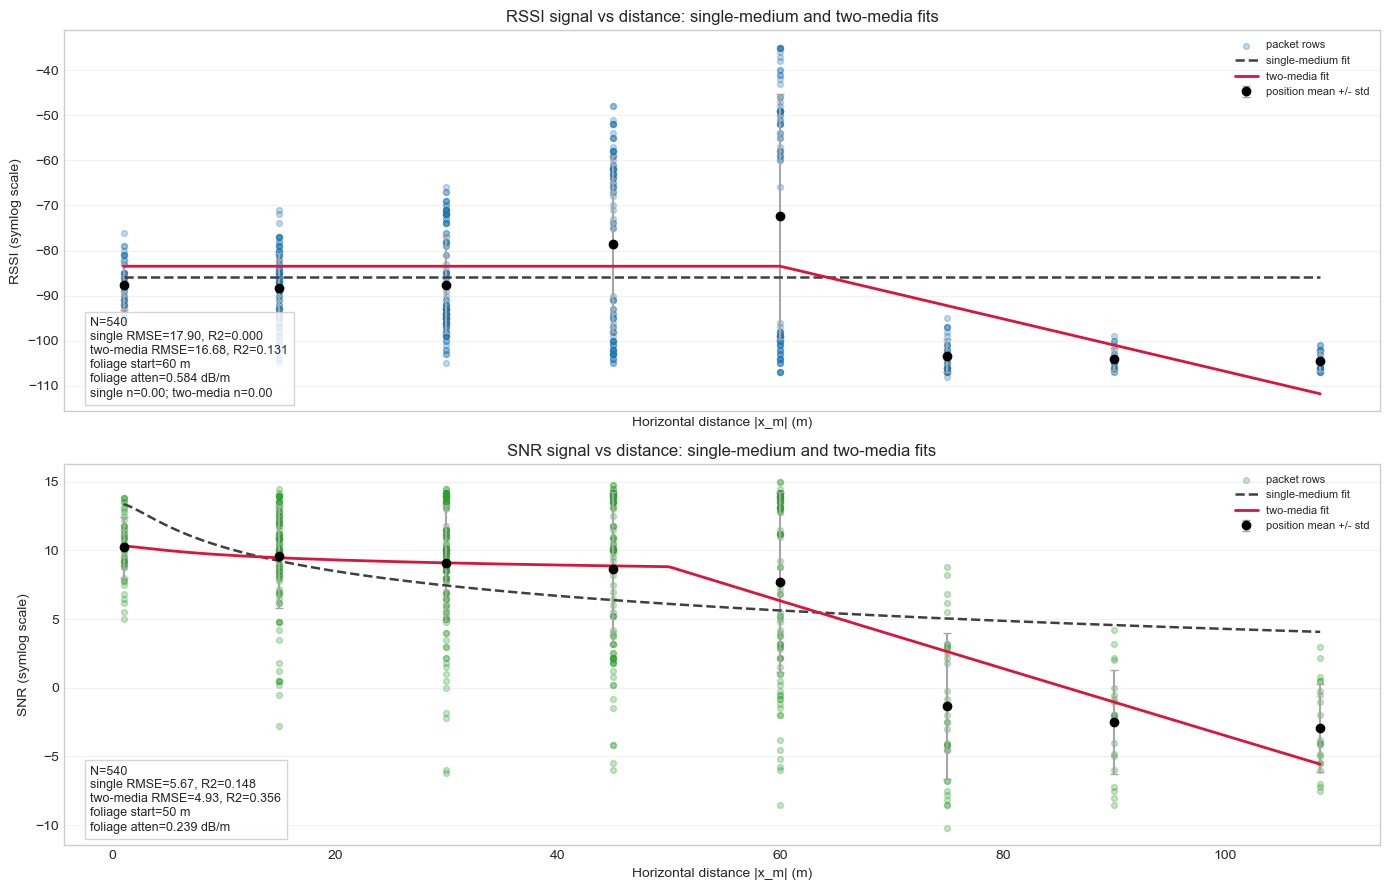

,model,metric,n_rows,intercept,attenuation_log10_path_db_per_dec,attenuation_foliage_db_per_m,beta_log10_path,beta_foliage_db_per_m,path_loss_n,bounded_lsq_status,r2,adj_r2,rmse,antenna_height_m,receiver_height_m,foliage_top_m,foliage_start_m,n_foliage_start_candidates
0,single_medium,rssi,540,-85.781481,1.907320e-21,0.000000,-1.907320e-21,0.000000,1.907320e-22,1,2.220446e-16,-0.001859,17.897663,4.5,1.5,3.5,NaN,0
1,two_media,rssi,540,-83.481015,7.410233e-18,0.583628,-7.410233e-18,-0.583628,7.410233e-19,1,1.312605e-01,0.128025,16.681731,4.5,1.5,3.5,60.0,16
2,single_medium,snr,540,16.410058,6.060832e+00,0.000000,-6.060832e+00,0.000000,NaN,3,1.482723e-01,0.146689,5.667809,4.5,1.5,3.5,NaN,0
3,two_media,snr,540,10.957227,1.258654e+00,0.238575,-1.258654e+00,-0.238575,NaN,3,3.559994e-01,0.353601,4.928423,4.5,1.5,3.5,50.0,16


In [24]:
ANTENNA_HEIGHT_M = 4.5
RECEIVER_HEIGHT_M = 1.5
FOLIAGE_TOP_M = 3.5
FOLIAGE_START_CANDIDATES_M = np.arange(0.0, 75.0 + 1e-9, 5.0)
REFERENCE_DISTANCE_M = 1.0
SYMLOG_LINTHRESH_DB = 1.0


def add_foliage_geometry(df: pd.DataFrame, foliage_start_m: float = 0.0) -> pd.DataFrame:
    out = df.copy()
    out["position_m"] = out["x_m"]
    out["horizontal_distance_m"] = out["x_m"].abs()
    height_delta_m = ANTENNA_HEIGHT_M - RECEIVER_HEIGHT_M
    out["path_3d_m"] = np.sqrt(out["horizontal_distance_m"] ** 2 + height_delta_m ** 2)

    if ANTENNA_HEIGHT_M <= FOLIAGE_TOP_M or ANTENNA_HEIGHT_M == RECEIVER_HEIGHT_M:
        canopy_entry_m = foliage_start_m
    else:
        entry_fraction = (ANTENNA_HEIGHT_M - FOLIAGE_TOP_M) / (ANTENNA_HEIGHT_M - RECEIVER_HEIGHT_M)
        canopy_entry_m = out["horizontal_distance_m"] * np.clip(entry_fraction, 0.0, 1.0)

    out["foliage_start_m"] = foliage_start_m
    out["foliage_entry_m"] = np.maximum(foliage_start_m, canopy_entry_m)
    out["foliage_length_m"] = (out["horizontal_distance_m"] - out["foliage_entry_m"]).clip(lower=0.0)
    out["log10_path_3d"] = np.log10(out["path_3d_m"].clip(lower=REFERENCE_DISTANCE_M) / REFERENCE_DISTANCE_M)
    return out


def fit_quality(y: np.ndarray, y_hat: np.ndarray, n_params: int) -> tuple[float, float, float, float, float]:
    residual = y - y_hat
    ss_res = float(np.sum(residual ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot else np.nan
    adj_r2 = 1.0 - (1.0 - r2) * (len(y) - 1) / (len(y) - n_params) if len(y) > n_params and np.isfinite(r2) else np.nan
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    sse = max(float(np.sum(residual ** 2)), 1e-12)
    aic = float(len(y) * np.log(sse / len(y)) + 2 * n_params)
    bic = float(len(y) * np.log(sse / len(y)) + n_params * np.log(len(y)))
    return r2, adj_r2, rmse, aic, bic


def solve_path_loss(fit_df: pd.DataFrame, metric: str, two_media: bool) -> dict:
    y = fit_df[metric].to_numpy(dtype=float)
    columns = [np.ones(len(fit_df)), -fit_df["log10_path_3d"].to_numpy(dtype=float)]
    lower = [-np.inf, 0.0]
    upper = [np.inf, np.inf]
    if two_media:
        columns.append(-fit_df["foliage_length_m"].to_numpy(dtype=float))
        lower.append(0.0)
        upper.append(np.inf)

    X = np.column_stack(columns)
    result = optimize.lsq_linear(X, y, bounds=(lower, upper))
    coeffs = result.x
    y_hat = X @ coeffs
    r2, adj_r2, rmse, aic, bic = fit_quality(y, y_hat, X.shape[1])

    foliage_atten = float(coeffs[2]) if two_media else 0.0
    return {
        "model": "two_media" if two_media else "single_medium",
        "metric": metric,
        "n_rows": int(len(fit_df)),
        "intercept": float(coeffs[0]),
        "attenuation_log10_path_db_per_dec": float(coeffs[1]),
        "attenuation_foliage_db_per_m": foliage_atten,
        "beta_log10_path": float(-coeffs[1]),
        "beta_foliage_db_per_m": -foliage_atten,
        "path_loss_n": float(coeffs[1] / 10) if metric == "rssi" else np.nan,
        "r2": float(r2),
        "adj_r2": float(adj_r2),
        "rmse": rmse,
        "aic": aic,
        "bic": bic,
        "antenna_height_m": ANTENNA_HEIGHT_M,
        "receiver_height_m": RECEIVER_HEIGHT_M,
        "foliage_top_m": FOLIAGE_TOP_M,
        "foliage_start_m": float(fit_df["foliage_start_m"].iloc[0]) if two_media else np.nan,
    }


def fit_single_medium_model(df: pd.DataFrame, metric: str) -> dict:
    fit_df = add_foliage_geometry(df[["x_m", metric]].dropna(), foliage_start_m=0.0)
    return solve_path_loss(fit_df, metric, two_media=False)


def fit_two_media_model(df: pd.DataFrame, metric: str) -> dict:
    base = df[["x_m", metric]].dropna()
    fits = []
    for foliage_start_m in FOLIAGE_START_CANDIDATES_M:
        fit_df = add_foliage_geometry(base, foliage_start_m=foliage_start_m)
        fits.append(solve_path_loss(fit_df, metric, two_media=True))
    best = min(fits, key=lambda item: item["rmse"])
    best["n_foliage_start_candidates"] = len(fits)
    return best


def predict_signal_model(fit: dict, x_m: np.ndarray) -> np.ndarray:
    foliage_start_m = 0.0 if pd.isna(fit.get("foliage_start_m", np.nan)) else fit["foliage_start_m"]
    pred = add_foliage_geometry(pd.DataFrame({"x_m": x_m}), foliage_start_m=foliage_start_m)
    return (
        fit["intercept"]
        + fit["beta_log10_path"] * pred["log10_path_3d"].to_numpy()
        + fit["beta_foliage_db_per_m"] * pred["foliage_length_m"].to_numpy()
    )


def plot_fit(ax, df: pd.DataFrame, metric: str, ylabel: str, single_fit: dict, two_media_fit: dict | None = None):
    plot_df = df[["x_m", metric, "structure_id", "manual_group"]].dropna().copy()
    summary = plot_df.groupby("x_m", as_index=False).agg(mean=(metric, "mean"), std=(metric, "std"), n=(metric, "count")).sort_values("x_m")

    ax.scatter(plot_df["x_m"], plot_df[metric], s=16, alpha=0.22, color="0.55", label="packets")
    ax.errorbar(summary["x_m"], summary["mean"], yerr=summary["std"], fmt="o", color="black", ecolor="0.70", capsize=3, label="mean +/- std")

    x_grid = np.linspace(plot_df["x_m"].min(), plot_df["x_m"].max(), 300)
    ax.plot(x_grid, predict_signal_model(single_fit, x_grid), color="0.25", linestyle="--", linewidth=2, label="single path-loss")
    text = f"single: R2={single_fit['r2']:.3f}, RMSE={single_fit['rmse']:.2f} dB"

    if two_media_fit is not None:
        ax.plot(x_grid, predict_signal_model(two_media_fit, x_grid), color="crimson", linewidth=2, label="two-media path-loss")
        text += f"\ntwo-media: R2={two_media_fit['r2']:.3f}, RMSE={two_media_fit['rmse']:.2f} dB"
        text += f"\nfoliage start={two_media_fit['foliage_start_m']:.0f} m, atten={two_media_fit['attenuation_foliage_db_per_m']:.3f} dB/m"

    ax.text(0.02, 0.03, text, transform=ax.transAxes, va="bottom", ha="left", fontsize=9, bbox=dict(facecolor="white", alpha=0.82, edgecolor="0.8"))
    ax.set_xlabel("Mapped physical position x_m (m)")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(False, axis="x")
    ax.legend(loc="best", fontsize=8)


rssi_single_fit = fit_single_medium_model(clean_data, "rssi")
snr_single_fit = fit_single_medium_model(clean_data, "snr")
rssi_two_media_fit = fit_two_media_model(clean_data, "rssi")
snr_two_media_fit = fit_two_media_model(clean_data, "snr")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plot_fit(axes[0], clean_data, "rssi", "Power / RSSI (dBm)", rssi_single_fit)
plot_fit(axes[1], clean_data, "snr", "SNR (dB)", snr_single_fit)
fig.suptitle("First fit: single path-loss medium", fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plot_fit(axes[0], clean_data, "rssi", "Power / RSSI (dBm)", rssi_single_fit, rssi_two_media_fit)
plot_fit(axes[1], clean_data, "snr", "SNR (dB)", snr_single_fit, snr_two_media_fit)
fig.suptitle("Single path-loss versus two-media path-loss", fontsize=14)
plt.tight_layout()
plt.show()

fit_summary = pd.DataFrame([rssi_single_fit, snr_single_fit, rssi_two_media_fit, snr_two_media_fit])
display(fit_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for metric, group in fit_summary.groupby("metric", sort=False):
    label_prefix = metric.upper()
    labels = [f"{label_prefix}\n{model}" for model in group["model"]]
    axes[0].bar(labels, group["rmse"], alpha=0.75)
    axes[1].bar(labels, group["adj_r2"], alpha=0.75)
    axes[2].bar(labels, group["bic"], alpha=0.75)

axes[0].set_title("RMSE, lower is better")
axes[0].set_ylabel("dB")
axes[1].set_title("Adjusted R2, higher is better")
axes[1].set_ylabel("Adjusted R2")
axes[2].set_title("BIC, lower is better")
axes[2].set_ylabel("BIC")
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## Fit Residuals

Residuals show where the physical model misses. If residuals are randomly scattered around zero, the fit is adequate. If residuals form structure by `x_m`, `structure_id`, group, or mirror side, then even the log-distance plus foliage-length model is still missing another physical effect, such as orientation, multipath, local crop density, or gateway-side obstruction.

,structure_id,manual_group,x_m,foliage_length_m,rows,mean_rssi_residual,mean_snr_residual
0,R1183,1,-60.0,0.0,4,35.231015,7.342284
11,R1185,1,-60.0,0.0,7,33.766730,6.424427
22,R1187,1,-60.0,0.0,6,33.981015,7.233951
33,R1189,1,-60.0,0.0,5,23.081015,7.907284
45,R1352,1,-60.0,0.0,7,32.195301,6.510142
56,R1354,1,-60.0,0.0,4,42.981015,5.717284
67,R1356,1,-60.0,0.0,8,47.731015,6.504784
79,R1358,1,-60.0,0.0,5,29.481015,6.627284
91,R1360,1,-60.0,0.0,4,29.731015,6.817284
1,R1183,2,-45.0,0.0,6,21.147682,3.508142


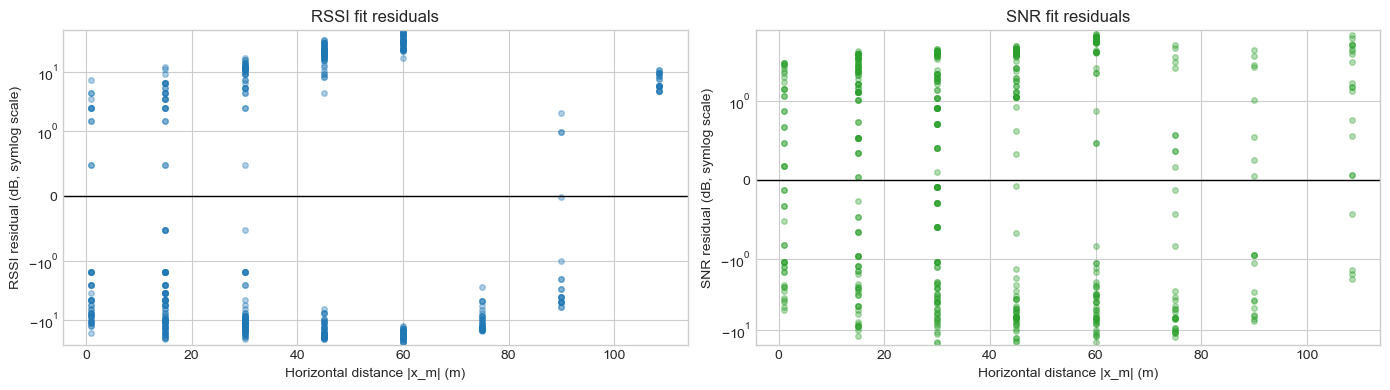

In [25]:
residual_df = add_foliage_geometry(clean_data[["structure_id", "manual_group", "x_m", "rssi", "snr"]].dropna(), foliage_start_m=rssi_two_media_fit["foliage_start_m"]).copy()
for fit in (rssi_two_media_fit, snr_two_media_fit):
    metric = fit["metric"]
    residual_df[f"{metric}_fit"] = predict_signal_model(fit, residual_df["x_m"].to_numpy())
    residual_df[f"{metric}_residual"] = residual_df[metric] - residual_df[f"{metric}_fit"]

residual_summary = residual_df.groupby(["structure_id", "manual_group", "x_m", "foliage_length_m"], dropna=False).agg(rows=("rssi", "count"), mean_rssi_residual=("rssi_residual", "mean"), mean_snr_residual=("snr_residual", "mean")).reset_index().sort_values(["x_m", "structure_id"])
display(residual_summary.head(30))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(residual_df["x_m"], residual_df["rssi_residual"], s=16, alpha=0.35, color="tab:blue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("RSSI fit residuals")
axes[0].set_yscale("symlog", linthresh=SYMLOG_LINTHRESH_DB)
axes[0].set_xlabel("Mapped physical position x_m (m)")
axes[0].set_ylabel("RSSI residual (dB, symlog scale)")
axes[1].scatter(residual_df["x_m"], residual_df["snr_residual"], s=16, alpha=0.35, color="tab:green")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("SNR fit residuals")
axes[1].set_yscale("symlog", linthresh=SYMLOG_LINTHRESH_DB)
axes[1].set_xlabel("Mapped physical position x_m (m)")
axes[1].set_ylabel("SNR residual (dB, symlog scale)")
plt.tight_layout()
plt.show()

## Longer-Sampling Distribution Study

For repeated measurements at a fixed position, RSSI and SNR often look approximately normal around a local mean because many small effects add together. Wireless measurements can also have heavier tails due to multipath, interference, timing, or orientation changes.

For each longer-sampling position, the code fits a normal distribution and a Student-t distribution. Lower AIC is better. If `delta_aic_t_minus_normal < 0`, the Student-t model is preferred; otherwise the normal model is preferred. Shapiro p-values are included as a rough normality check.

In [26]:
def distribution_fit_table(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    rows = []
    group_cols = ["longer_sampling_source", "structure_id", "manual_group", "x_m"]
    for key, group in df.groupby(group_cols, dropna=False):
        values = group[metric].dropna().to_numpy()
        if len(values) < 3:
            continue
        source, structure_id, manual_group, x_m = key
        mu, sigma = stats.norm.fit(values)
        sigma = max(float(sigma), 1e-9)
        normal_loglik = float(np.sum(stats.norm.logpdf(values, mu, sigma)))
        normal_aic = 2 * 2 - 2 * normal_loglik
        try:
            t_df, t_loc, t_scale = stats.t.fit(values)
            t_scale = max(float(t_scale), 1e-9)
            t_loglik = float(np.sum(stats.t.logpdf(values, t_df, loc=t_loc, scale=t_scale)))
            t_aic = 2 * 3 - 2 * t_loglik
        except Exception:
            t_df, t_loc, t_scale, t_aic = np.nan, np.nan, np.nan, np.nan
        shapiro_p = stats.shapiro(values).pvalue if 3 <= len(values) <= 5000 else np.nan
        rows.append({
            "metric": metric,
            "longer_sampling_source": source,
            "structure_id": structure_id,
            "manual_group": manual_group,
            "x_m": x_m,
            "n": len(values),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else np.nan,
            "median": float(np.median(values)),
            "normal_mu": float(mu),
            "normal_sigma": float(sigma),
            "normal_aic": float(normal_aic),
            "t_df": float(t_df),
            "t_loc": float(t_loc),
            "t_scale": float(t_scale),
            "t_aic": float(t_aic),
            "delta_aic_t_minus_normal": float(t_aic - normal_aic) if np.isfinite(t_aic) else np.nan,
            "shapiro_p": float(shapiro_p),
        })
    return pd.DataFrame(rows).sort_values(["metric", "longer_sampling_source", "structure_id", "manual_group"])


distribution_summary = pd.concat([distribution_fit_table(longer_sampling, "rssi"), distribution_fit_table(longer_sampling, "snr")], ignore_index=True)
display(distribution_summary)

model_preference = (
    distribution_summary.assign(preferred=np.where(distribution_summary["delta_aic_t_minus_normal"] < 0, "student_t", "normal"))
    .groupby(["metric", "preferred"])
    .size()
    .rename("positions")
    .reset_index()
)
display(model_preference)

,metric,longer_sampling_source,structure_id,manual_group,x_m,n,mean,std,median,normal_mu,normal_sigma,normal_aic,t_df,t_loc,t_scale,t_aic,delta_aic_t_minus_normal,shapiro_p
0,rssi,group_7,R1187,7,30.0,22,-95.045455,2.170742,-95.00,-95.045455,2.120833,99.512895,4.114318e+04,-95.045347,2.120615,101.511162,1.998268,8.279579e-05
1,rssi,group_7,R1189,7,30.0,14,-98.428571,2.173770,-99.00,-98.428571,2.094697,64.433727,4.115462e+04,-98.428601,2.094650,66.433751,2.000024,1.605212e-01
2,rssi,group_7,R1352,7,30.0,15,-94.066667,1.334523,-94.00,-94.066667,1.289272,54.190487,4.162882e+04,-94.066647,1.289244,56.190528,2.000041,2.235114e-01
3,rssi,tail,R1183,13,120.0,30,-92.166667,8.538284,-94.50,-92.166667,8.394774,216.792871,3.882162e+04,-92.166779,8.394680,218.793308,2.000437,3.697782e-03
4,rssi,tail,R1185,13,120.0,45,-96.377778,3.249398,-97.00,-96.377778,3.213091,236.755460,3.481292e+04,-96.378041,3.212587,238.749707,1.994246,1.695444e-09
5,rssi,tail,R1356,13,120.0,10,-84.900000,2.469818,-84.00,-84.900000,2.343075,49.408053,1.526301e+04,-84.899785,2.342900,51.407961,1.999908,2.419043e-04
6,rssi,tail,R1358,13,120.0,29,-87.793103,9.813909,-91.00,-87.793103,9.643219,217.741225,3.797527e+04,-87.793394,9.642855,219.740894,1.999669,4.896679e-03
7,rssi,tail,R1360,13,120.0,37,-87.459459,9.728522,-89.00,-87.459459,9.596155,276.342278,3.771523e+04,-87.459698,9.595901,278.342277,1.999999,1.471581e-03
8,snr,group_7,R1187,7,30.0,22,7.800000,2.314139,8.65,7.800000,2.260933,102.327509,1.433877e+00,8.631049,0.909234,97.942957,-4.384552,6.425461e-04
9,snr,group_7,R1189,7,30.0,14,5.450000,2.157545,5.00,5.450000,2.079062,64.223954,1.925754e+00,5.027752,1.143633,65.256408,1.032454,2.477630e-01


,metric,preferred,positions
0,rssi,normal,8
1,snr,normal,7
2,snr,student_t,1


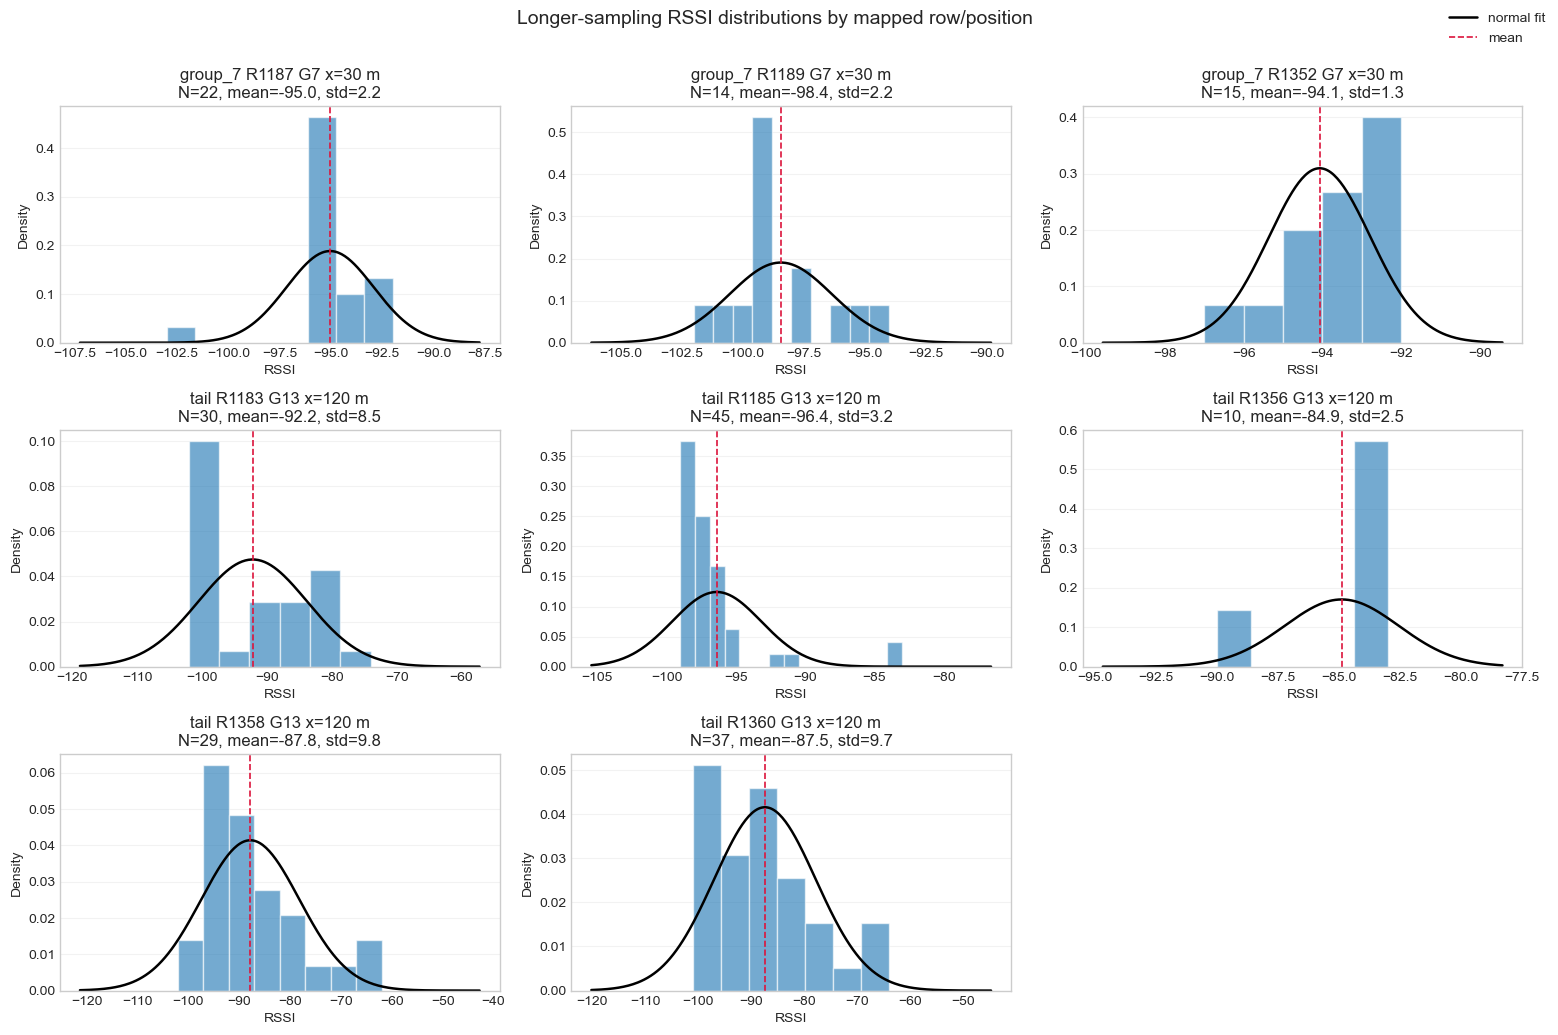

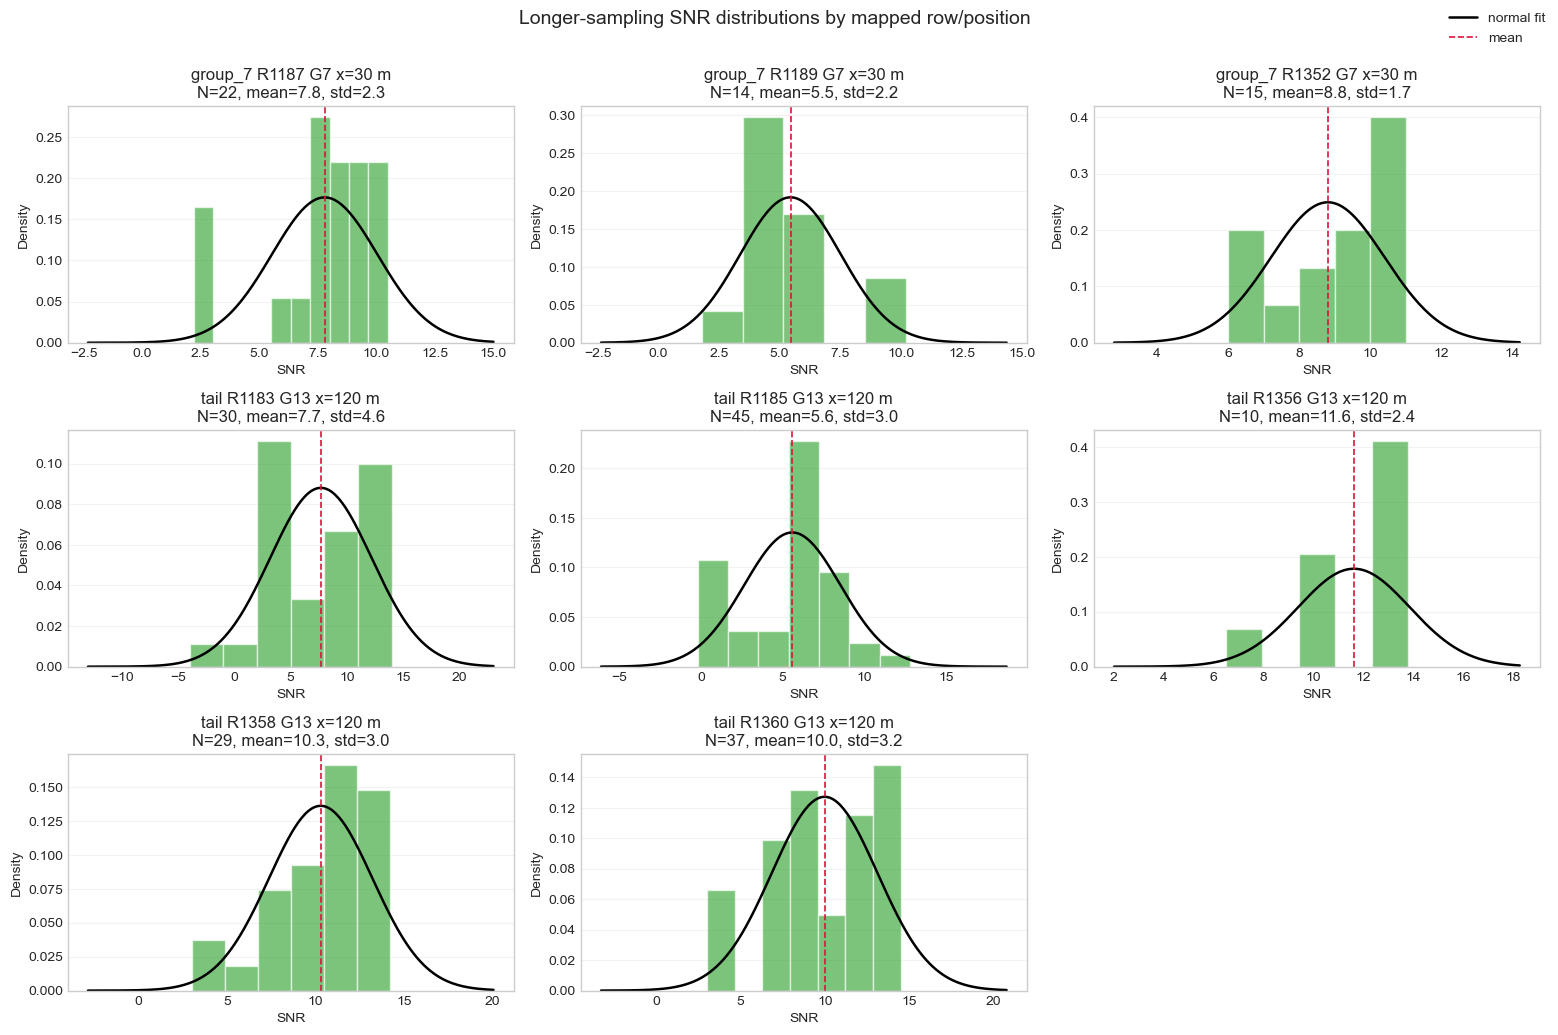

In [27]:
def plot_longer_sampling_distributions(df: pd.DataFrame, metric: str):
    group_cols = ["longer_sampling_source", "structure_id", "manual_group", "x_m"]
    groups = [(key, group[metric].dropna().to_numpy()) for key, group in df.groupby(group_cols, dropna=False) if group[metric].notna().sum() >= 3]
    ncols = 3
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, (key, values) in zip(axes, groups):
        source, structure_id, manual_group, x_m = key
        ax.hist(values, bins="auto", density=True, alpha=0.62, color="tab:blue" if metric == "rssi" else "tab:green", edgecolor="white")
        mu, sigma = stats.norm.fit(values)
        sigma = max(float(sigma), 1e-9)
        x_grid = np.linspace(values.min() - 2 * sigma, values.max() + 2 * sigma, 250)
        ax.plot(x_grid, stats.norm.pdf(x_grid, mu, sigma), color="black", linewidth=1.8, label="normal fit")
        ax.axvline(np.mean(values), color="crimson", linewidth=1.2, linestyle="--", label="mean")
        ax.set_title(f"{source} {structure_id} G{int(manual_group)} x={x_m:g} m\nN={len(values)}, mean={np.mean(values):.1f}, std={np.std(values, ddof=1):.1f}")
        ax.set_xlabel(metric.upper())
        ax.set_ylabel("Density")
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(False, axis="x")
    for ax in axes[len(groups):]:
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(f"Longer-sampling {metric.upper()} distributions by mapped row/position", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_longer_sampling_distributions(longer_sampling, "rssi")
plot_longer_sampling_distributions(longer_sampling, "snr")

## Distribution Interpretation

Use the `distribution_summary` table together with the histograms:

- A roughly symmetric histogram with lower normal AIC means a normal model is reasonable.
- A lower Student-t AIC means heavier tails are likely, so occasional strong or weak packets occur more often than Gaussian noise would predict.
- If `N` is small, treat model choice cautiously. The longer-sampling rows help because larger `N` makes this distribution study more meaningful.

A small standard deviation and normal-looking histogram indicate stable reception at that position. Large spread or heavy tails suggest transient propagation, multipath, interference, or packet-level variability.